In [1]:
import pandas as pd

In [2]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/Cell/
%pwd

/home/jovyan/work/COVID/parameter_tuning/binary/Cell


'/home/jovyan/work/COVID/parameter_tuning/binary/Cell'

In [3]:
# import the distance data
distance_ctrl = pd.read_csv("distance_ctrl.csv", index_col=0)

# distance_NA = pd.read_csv("distance_NA.csv", index_col=0)
distance_ctrl

,AL627309.1,AL627309.4,AL732372.1,AL669831.2,AL669831.5,LINC00115,FAM41C,AL645608.7,AL645608.3,AL645608.5,...,AL592183.1,AC007325.1,AC007325.4,AC007325.2,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1
AL627309.1,0.0,3.0,3.0,3.0,3.0,3.0,6.0,4.0,2.0,2.0,...,5.0,4.0,5.0,3.0,3.0,4.0,6.0,4.0,4.0,5.0
AL627309.4,3.0,0.0,4.0,2.0,2.0,2.0,5.0,3.0,1.0,1.0,...,4.0,4.0,5.0,4.0,2.0,5.0,5.0,4.0,4.0,4.0
AL732372.1,3.0,4.0,0.0,4.0,4.0,4.0,4.0,2.0,4.0,3.0,...,4.0,4.0,4.0,2.0,3.0,4.0,6.0,2.0,2.0,4.0
AL669831.2,3.0,2.0,4.0,0.0,3.0,3.0,5.0,3.0,2.0,2.0,...,5.0,4.0,4.0,4.0,2.0,5.0,6.0,4.0,4.0,5.0
AL669831.5,3.0,2.0,4.0,3.0,0.0,1.0,5.0,3.0,2.0,2.0,...,4.0,4.0,5.0,4.0,3.0,5.0,6.0,4.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC023491.2,4.0,5.0,4.0,5.0,5.0,4.0,5.0,4.0,4.0,4.0,...,5.0,3.0,5.0,4.0,4.0,0.0,7.0,5.0,5.0,5.0
AC004556.1,6.0,5.0,6.0,6.0,6.0,5.0,4.0,5.0,5.0,5.0,...,6.0,6.0,6.0,5.0,5.0,7.0,0.0,6.0,7.0,4.0
AC233755.2,4.0,4.0,2.0,4.0,4.0,3.0,5.0,3.0,3.0,3.0,...,4.0,4.0,4.0,3.0,3.0,5.0,6.0,0.0,2.0,3.0
AC233755.1,4.0,4.0,2.0,4.0,4.0,4.0,5.0,3.0,4.0,4.0,...,5.0,5.0,4.0,3.0,3.0,5.0,7.0,2.0,0.0,4.0


In [4]:
# Set the name of the DataFrame
distance_ctrl.name = "distance_ctrl"

# distance_NA.name = "distance_NA"

construct a weighted graph as leiden's input from the 50-PC distance space. Using Euclidean distance in the space, selecting top k% shortest distance as edges, normalize the distance to between 0-1, and then take the reciprocal to make smaller distances larger weights and vice versa

In [5]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from methods import distance_to_module_reciprocal, module_to_json

In [6]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/knd_reciprocal/Cell/
%pwd

/home/jovyan/work/COVID/parameter_tuning/binary/knd_reciprocal/Cell


'/home/jovyan/work/COVID/parameter_tuning/binary/knd_reciprocal/Cell'

Cell: resolution = 0.35

threshold_percentile = 40%: threshold_distance = 175.05427729707148
Number of connected components: 1


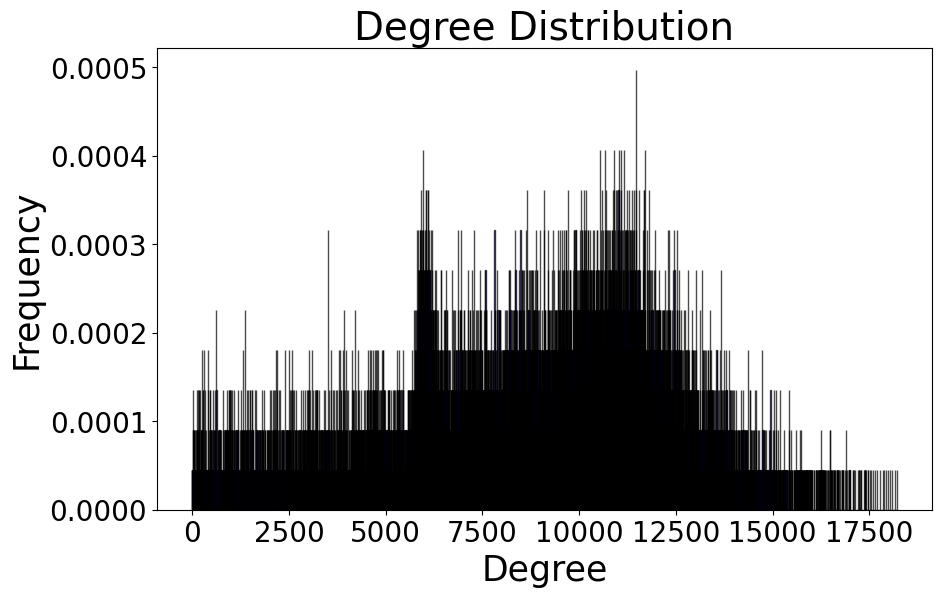

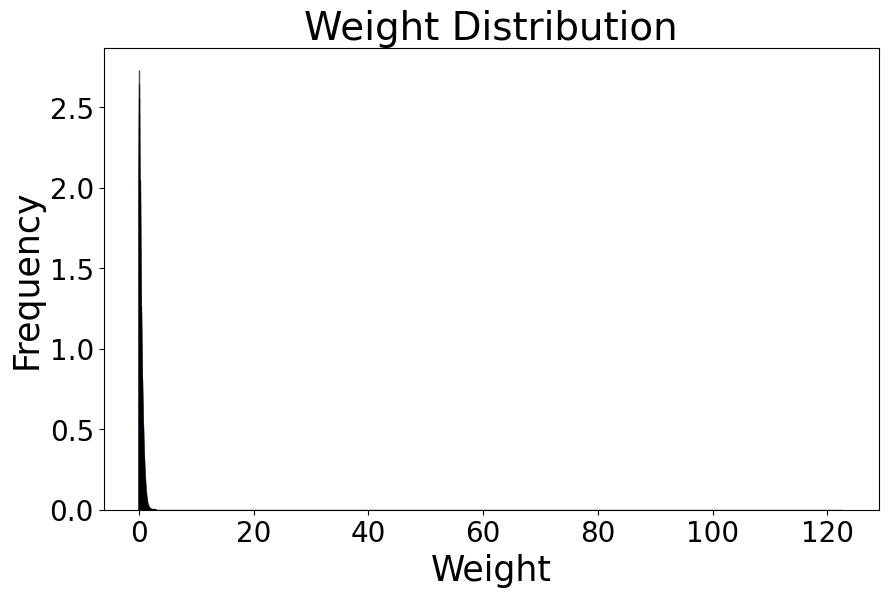

Number of clusters: 169
Cluster assignments: [23, 0, 2, 4, 0, 0, 17, 1, 0, 0, 1, 6, 0, 0, 7, 10, 54, 34, 0, 7]
Number of modules: 114


In [7]:
# resolution_values = [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]  # for 30%: 45~390 modules
resolution_values = [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]  # for 40%: 20~260 modules

# cannot calculate distance since it takes too long for a denser graph
for resolution_parameter in resolution_values:
    module_ctrl = distance_to_module_reciprocal(distance_coordinate=distance_ctrl, fig_path1=f"./figures/degree_distribution_ctrl_{resolution_parameter}.png", fig_path2=f"./figures/weight_distribution_ctrl_{resolution_parameter}.png", threshold_percentile=40, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_ctrl, file_path=f"module_ctrl_{resolution_parameter}.json")

In [8]:
del distance_ctrl
del module_ctrl

In [9]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/Cell/
%pwd

distance_mild = pd.read_csv("distance_mild.csv", index_col=0)
distance_mild.name = "distance_mild"

/home/jovyan/work/COVID/parameter_tuning/binary/Cell


/home/jovyan/work/COVID/parameter_tuning/binary/knd_reciprocal/Cell
threshold_percentile = 40%: threshold_distance = 181.31464364468746
Number of connected components: 1


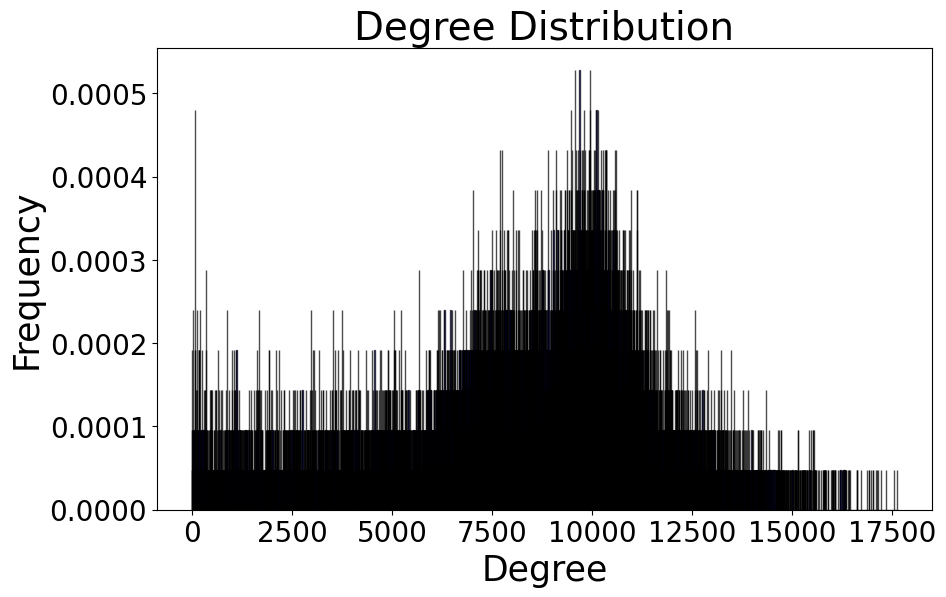

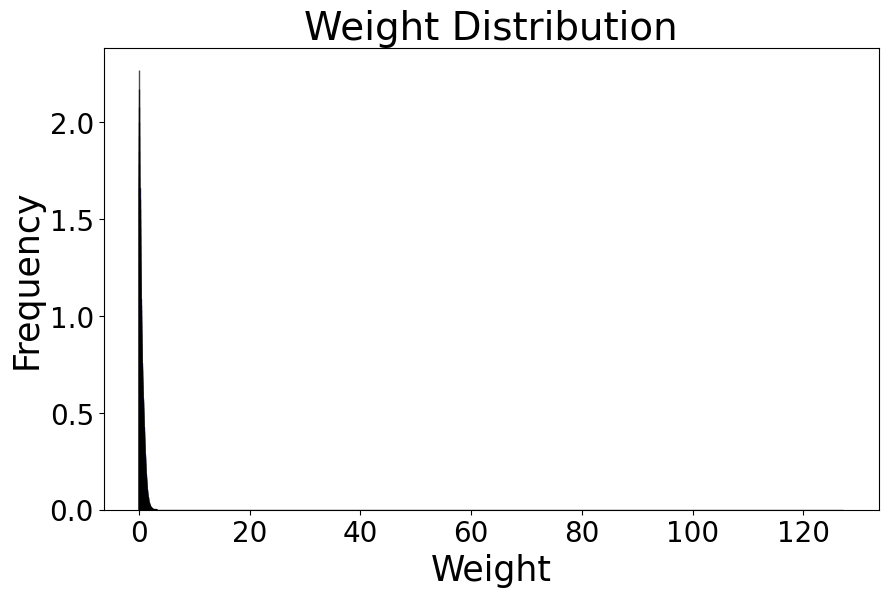

Number of clusters: 20
Cluster assignments: [1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 4, 3, 1, 1, 2, 1, 1, 1, 1]
Number of modules: 15
threshold_percentile = 40%: threshold_distance = 181.31464364468746
Number of connected components: 1


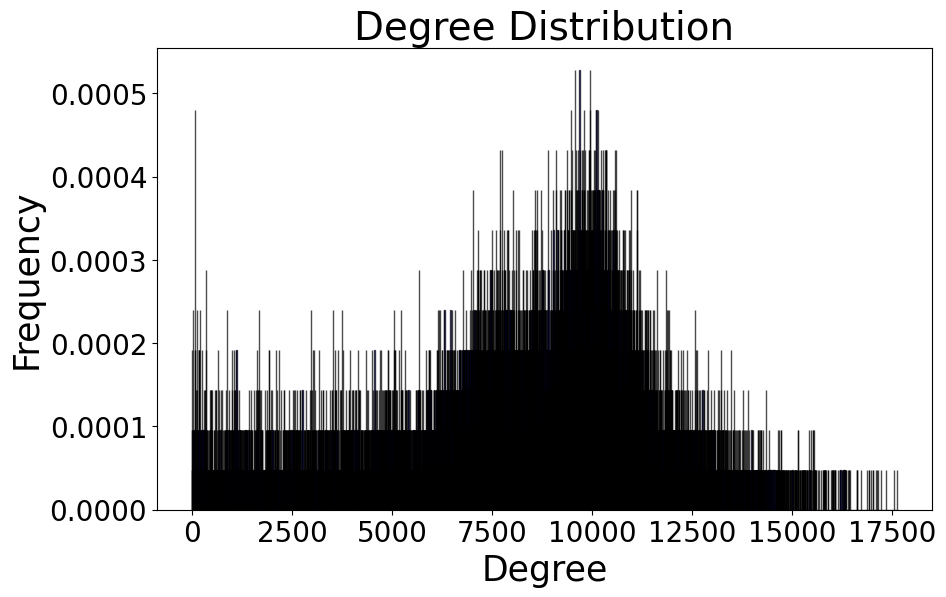

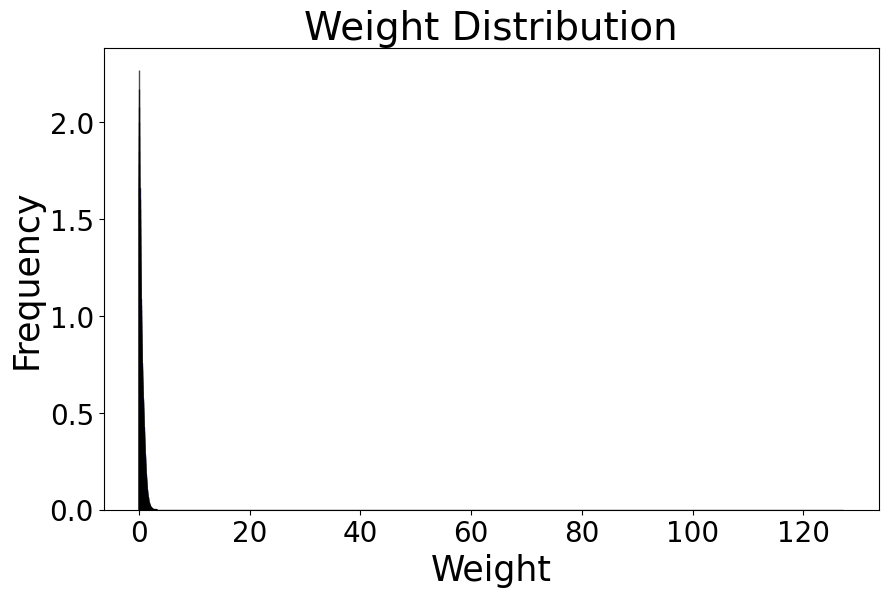

Number of clusters: 28
Cluster assignments: [1, 0, 4, 0, 0, 2, 2, 0, 0, 0, 4, 4, 3, 3, 1, 4, 1, 1, 1, 1]
Number of modules: 20
threshold_percentile = 40%: threshold_distance = 181.31464364468746
Number of connected components: 1


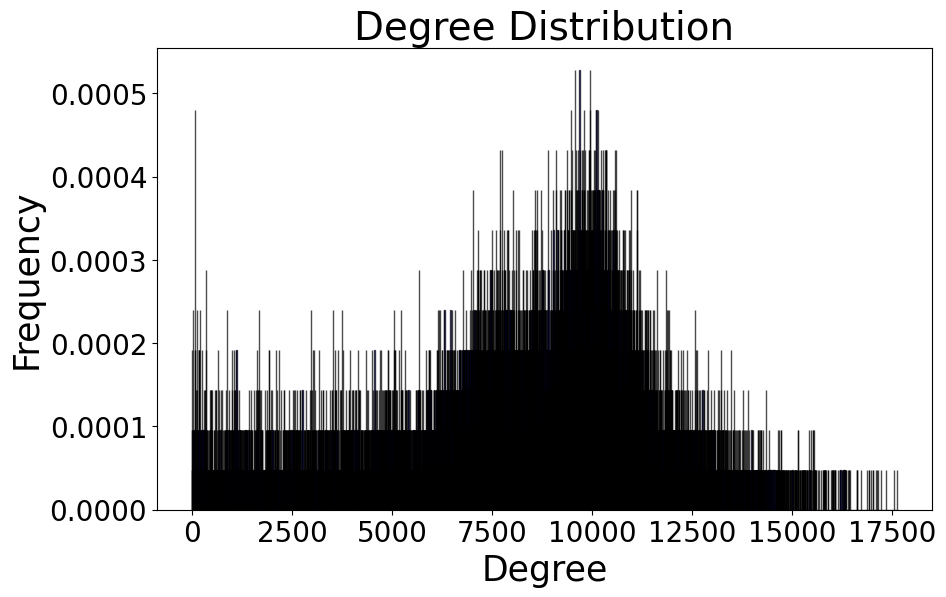

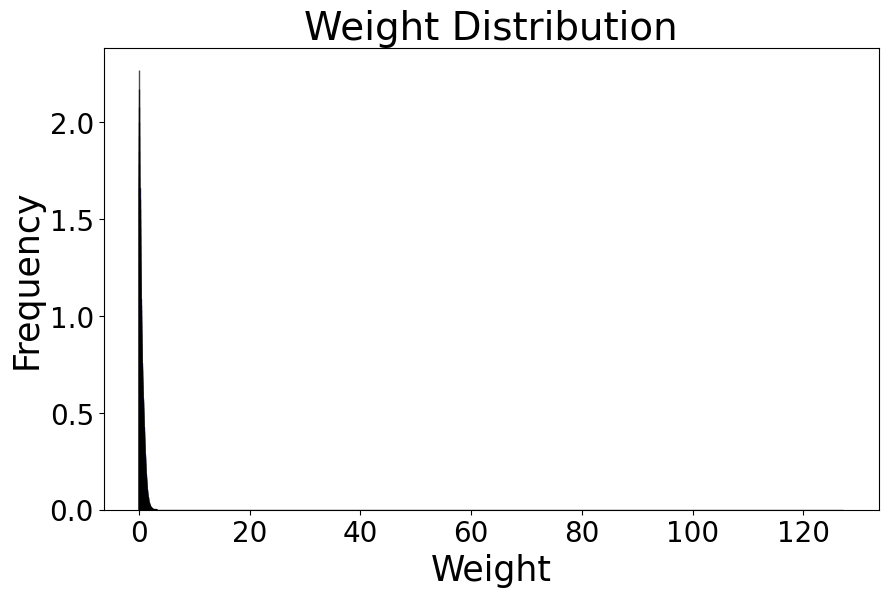

Number of clusters: 33
Cluster assignments: [5, 0, 4, 0, 0, 2, 2, 0, 0, 0, 5, 4, 3, 3, 1, 4, 1, 1, 1, 1]
Number of modules: 27
threshold_percentile = 40%: threshold_distance = 181.31464364468746
Number of connected components: 1


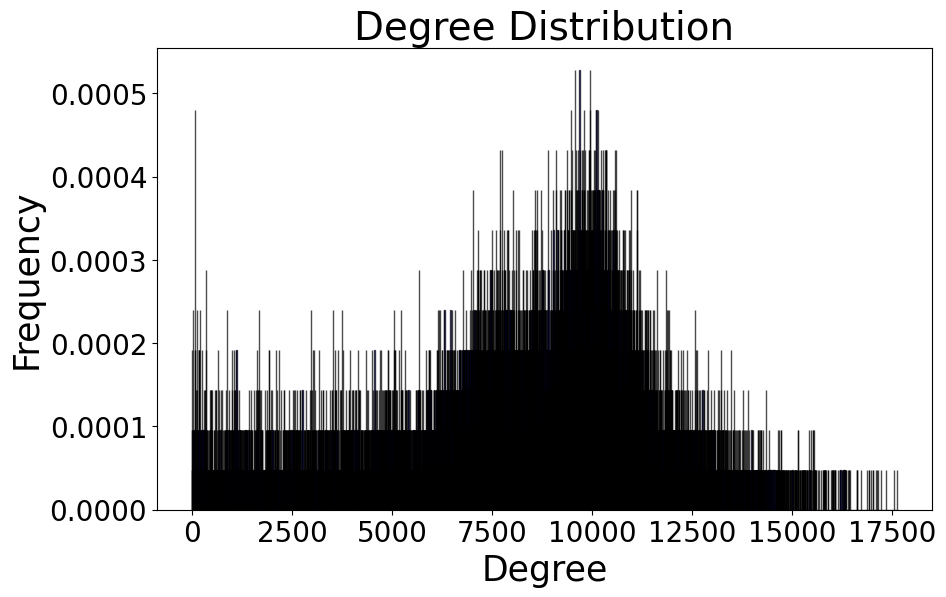

Number of clusters: 41
Cluster assignments: [5, 0, 4, 0, 0, 2, 2, 0, 0, 0, 5, 7, 3, 3, 1, 7, 3, 1, 3, 1]
Number of modules: 32
threshold_percentile = 40%: threshold_distance = 181.31464364468746
Number of connected components: 1


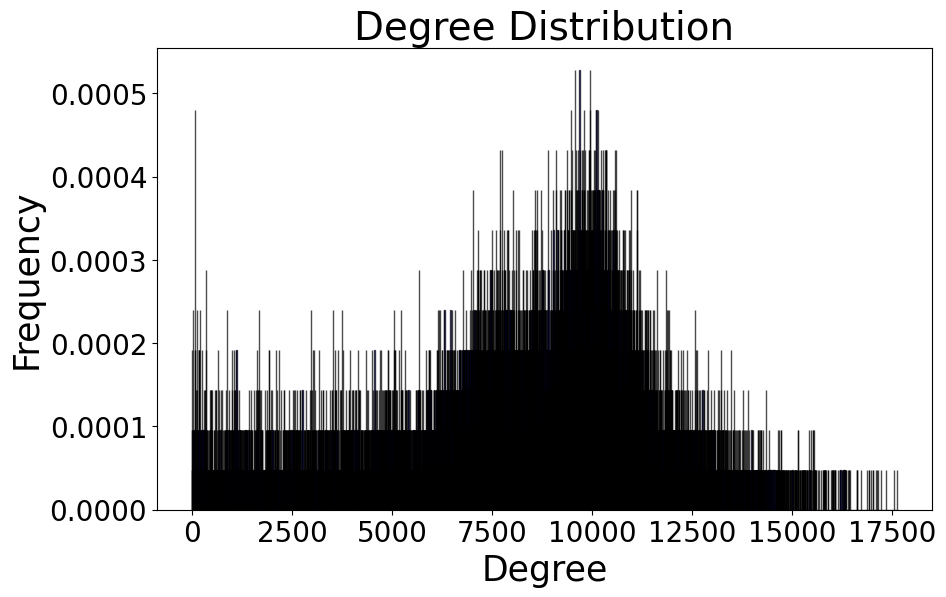

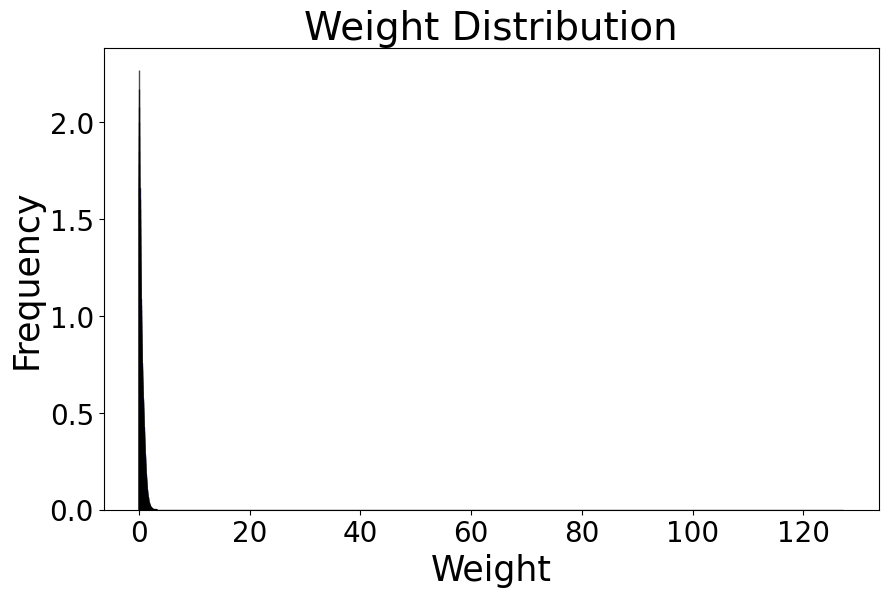

Number of clusters: 55
Cluster assignments: [5, 0, 4, 0, 0, 2, 2, 0, 0, 0, 5, 7, 3, 3, 3, 7, 3, 1, 3, 1]
Number of modules: 40
threshold_percentile = 40%: threshold_distance = 181.31464364468746
Number of connected components: 1


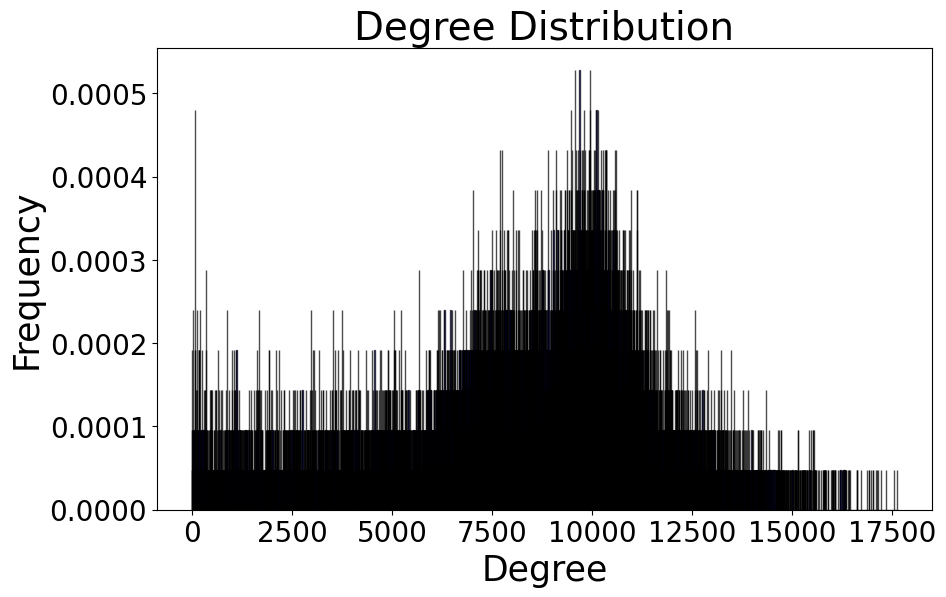

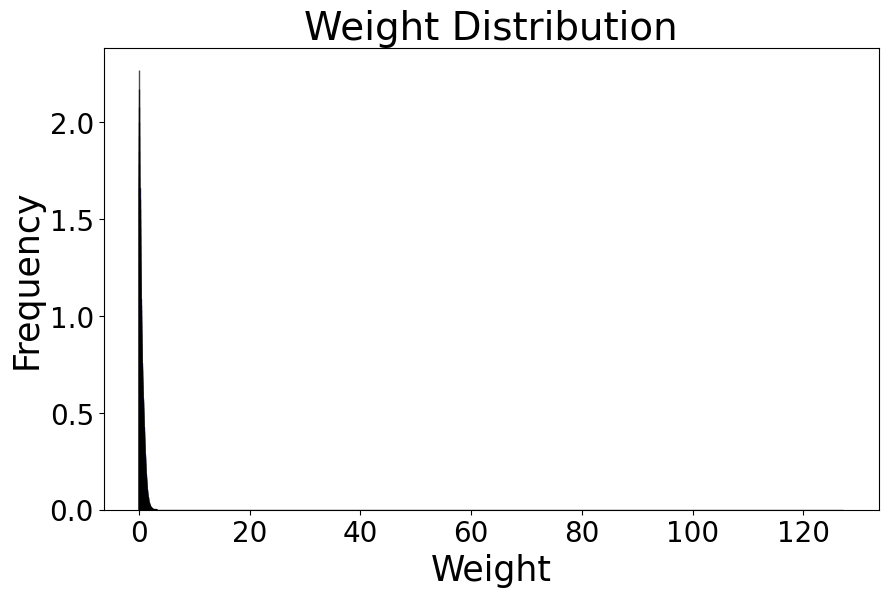

Number of clusters: 69
Cluster assignments: [6, 0, 5, 0, 0, 4, 4, 0, 0, 0, 6, 8, 7, 13, 2, 8, 2, 1, 2, 1]
Number of modules: 45
threshold_percentile = 40%: threshold_distance = 181.31464364468746
Number of connected components: 1


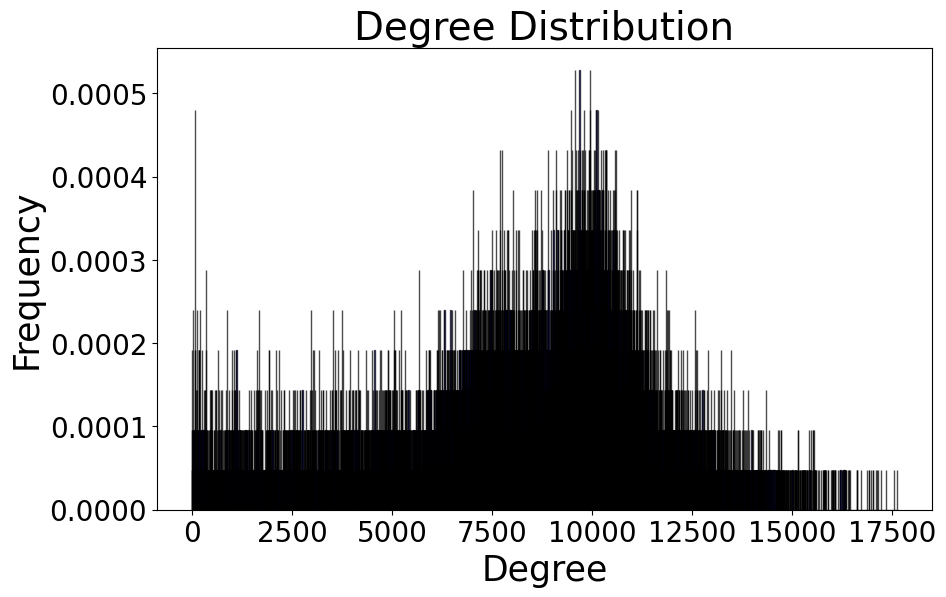

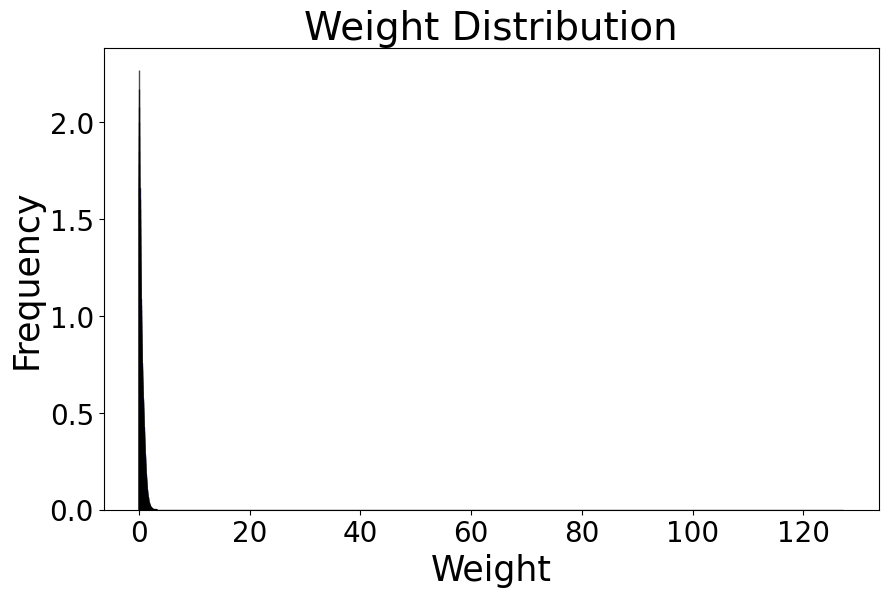

Number of clusters: 78
Cluster assignments: [6, 3, 5, 0, 0, 4, 20, 0, 0, 0, 6, 8, 7, 16, 2, 8, 2, 1, 2, 1]
Number of modules: 55
threshold_percentile = 40%: threshold_distance = 181.31464364468746
Number of connected components: 1


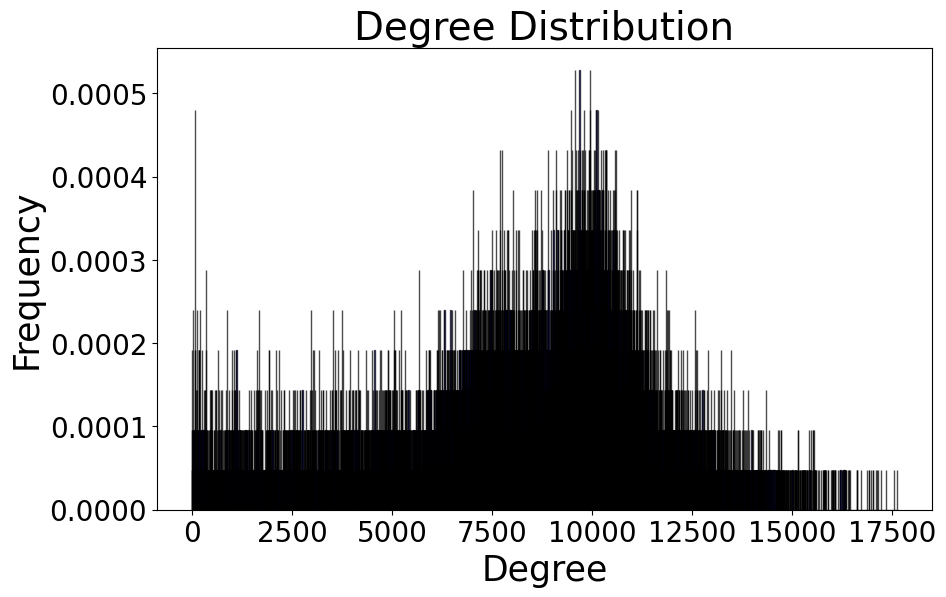

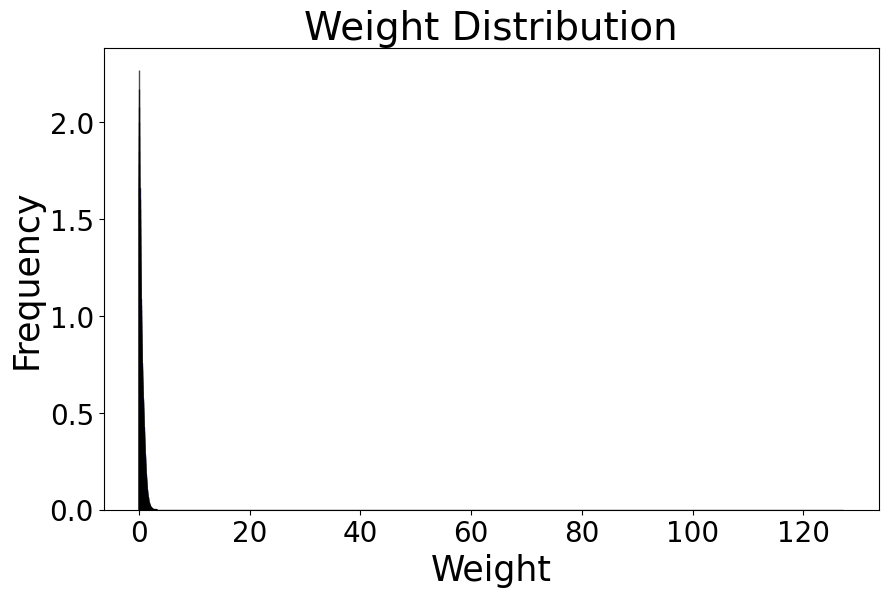

Number of clusters: 98
Cluster assignments: [6, 2, 5, 2, 2, 4, 15, 0, 2, 2, 6, 8, 7, 18, 3, 9, 3, 1, 3, 1]
Number of modules: 68
threshold_percentile = 40%: threshold_distance = 181.31464364468746
Number of connected components: 1


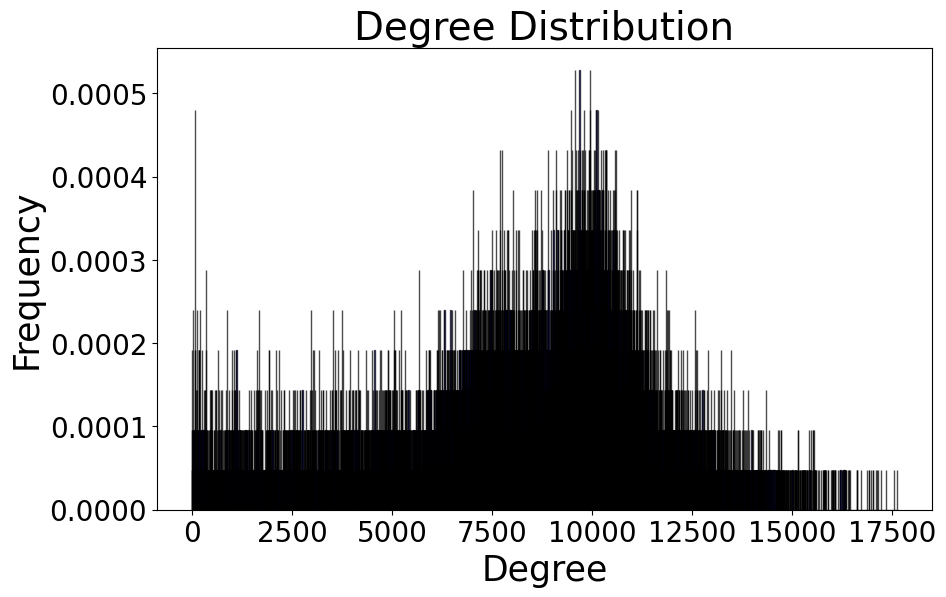

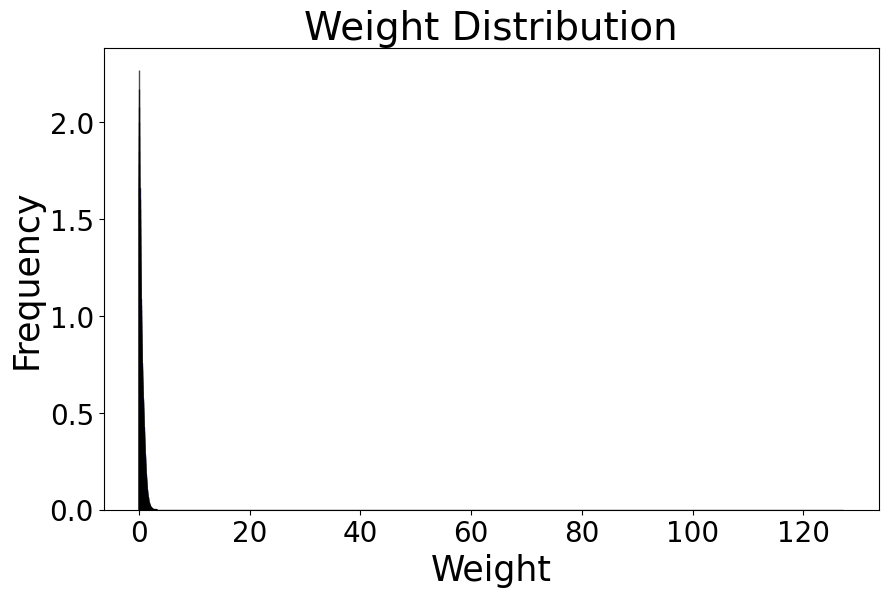

Number of clusters: 120
Cluster assignments: [7, 2, 5, 2, 21, 4, 14, 0, 2, 2, 9, 8, 6, 19, 3, 8, 3, 1, 3, 1]
Number of modules: 78


In [10]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/knd_reciprocal/Cell/
%pwd

for resolution_parameter in resolution_values:
    module_mild = distance_to_module_reciprocal(distance_coordinate=distance_mild, fig_path1=f"./figures/degree_distribution_mild_{resolution_parameter}.png", fig_path2=f"./figures/weight_distribution_mild_{resolution_parameter}.png", threshold_percentile=40, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_mild, file_path=f"module_mild_{resolution_parameter}.json")

In [11]:
del distance_mild
del module_mild

In [12]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/Cell/
%pwd

distance_severe = pd.read_csv("distance_severe.csv", index_col=0)
distance_severe.name = "distance_severe"

/home/jovyan/work/COVID/parameter_tuning/binary/Cell


/home/jovyan/work/COVID/parameter_tuning/binary/knd_reciprocal/Cell
threshold_percentile = 40%: threshold_distance = 265.29794571387094
Number of connected components: 1


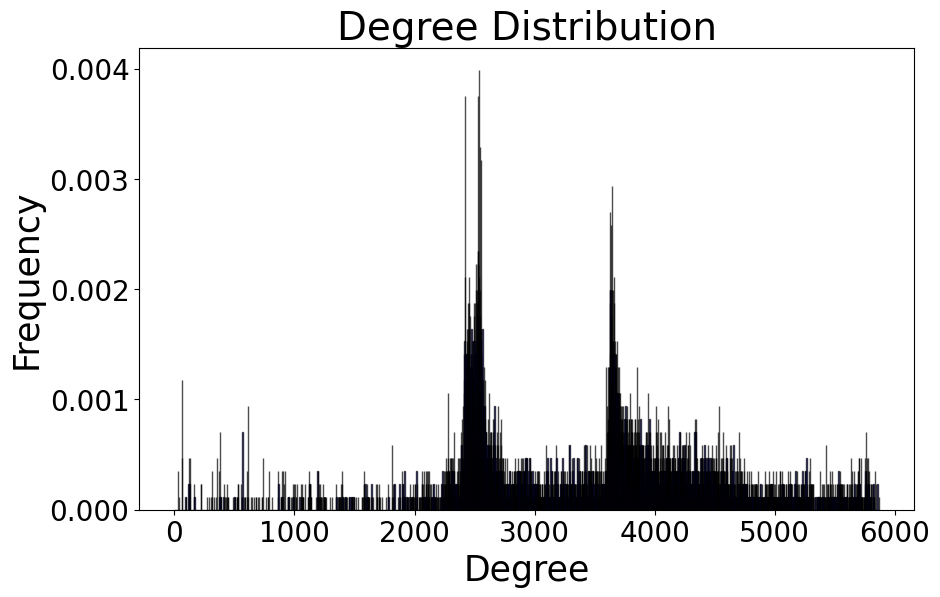

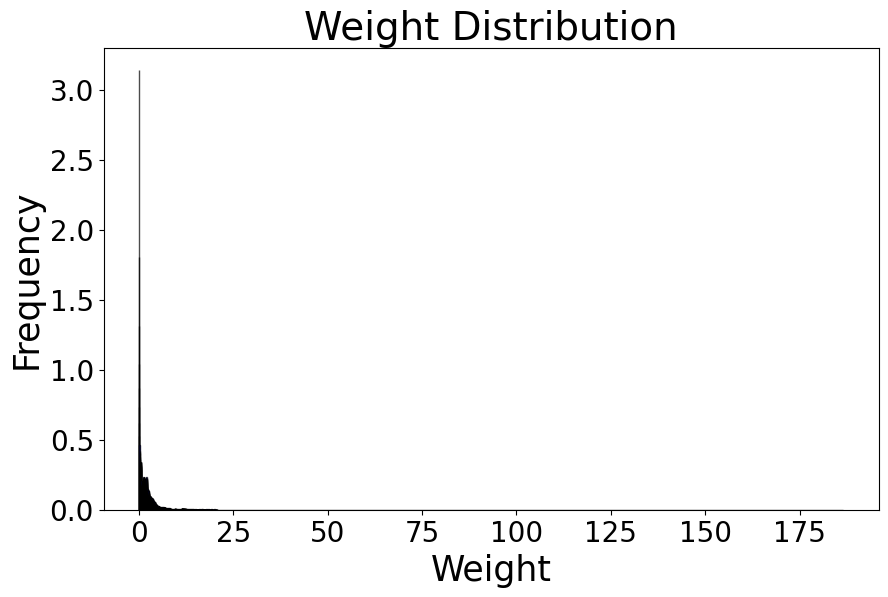

Number of clusters: 7
Cluster assignments: [2, 2, 0, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 2]
Number of modules: 7
threshold_percentile = 40%: threshold_distance = 265.29794571387094
Number of connected components: 1


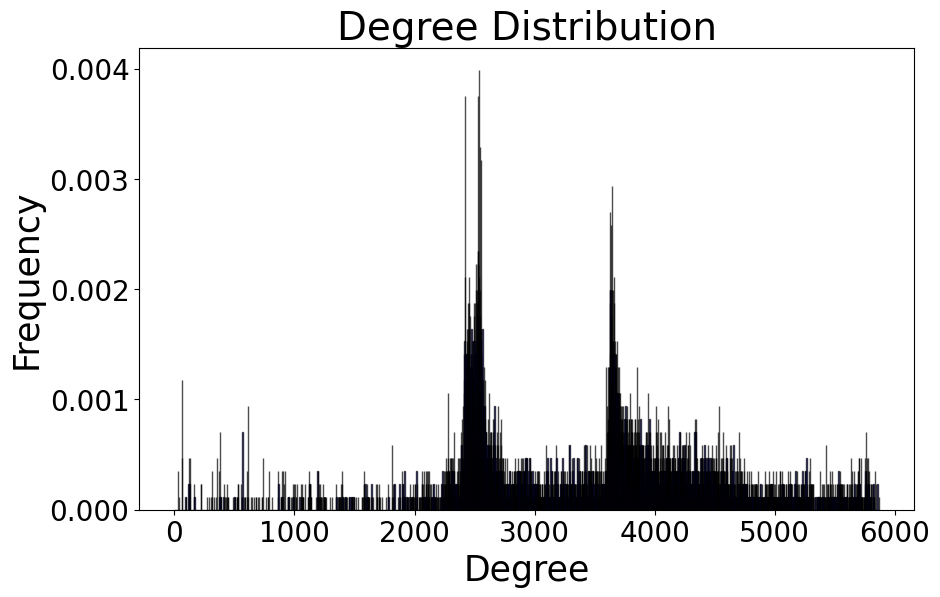

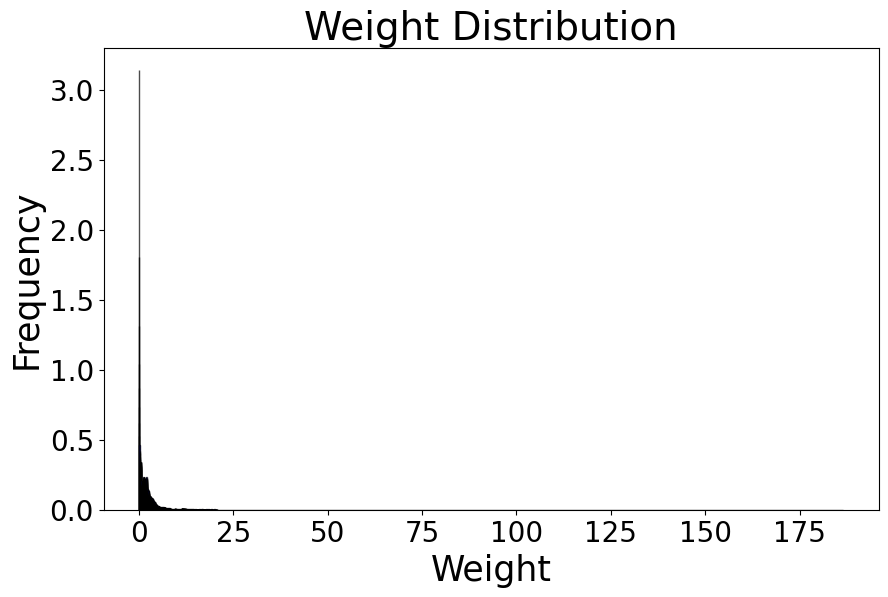

Number of clusters: 7
Cluster assignments: [2, 2, 0, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 2]
Number of modules: 7
threshold_percentile = 40%: threshold_distance = 265.29794571387094
Number of connected components: 1


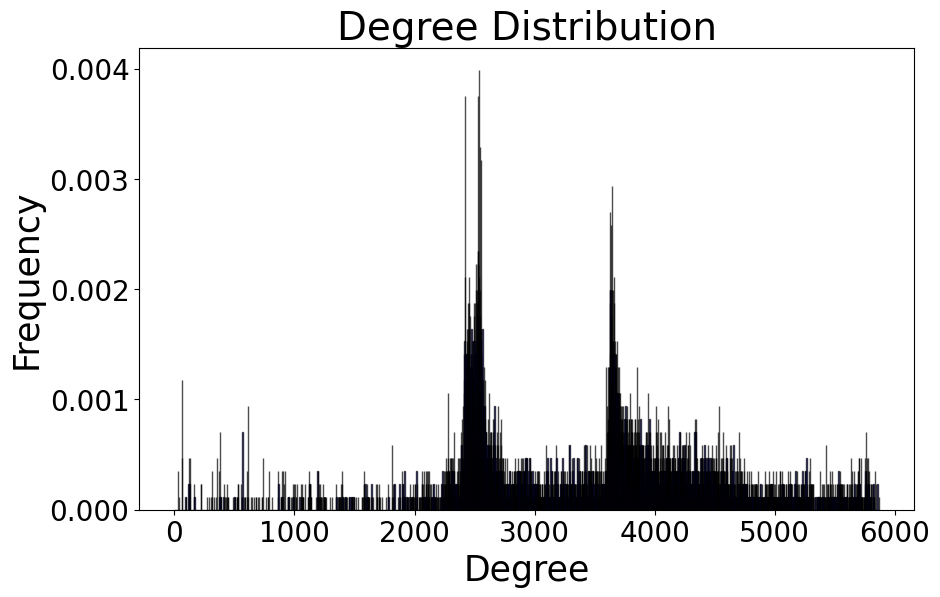

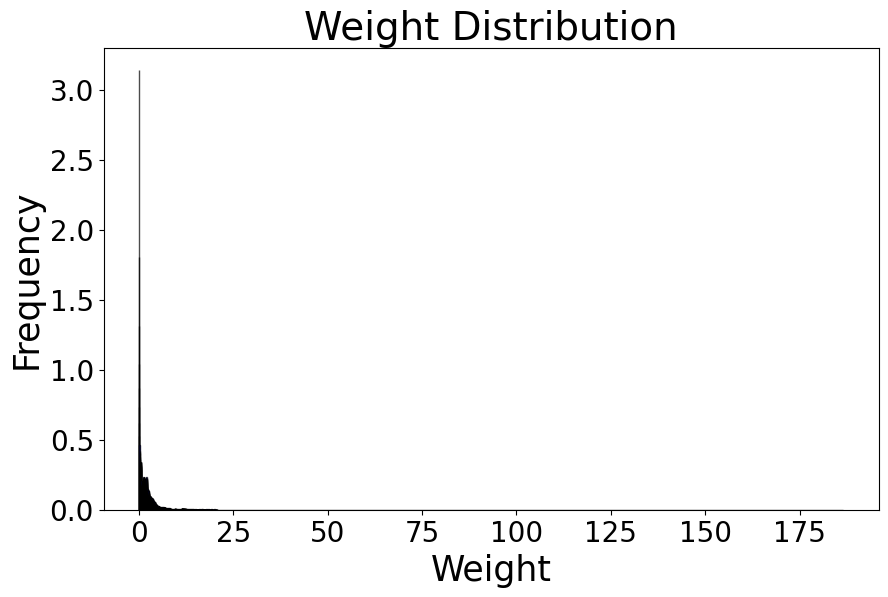

Number of clusters: 9
Cluster assignments: [2, 2, 0, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 2]
Number of modules: 8
threshold_percentile = 40%: threshold_distance = 265.29794571387094
Number of connected components: 1


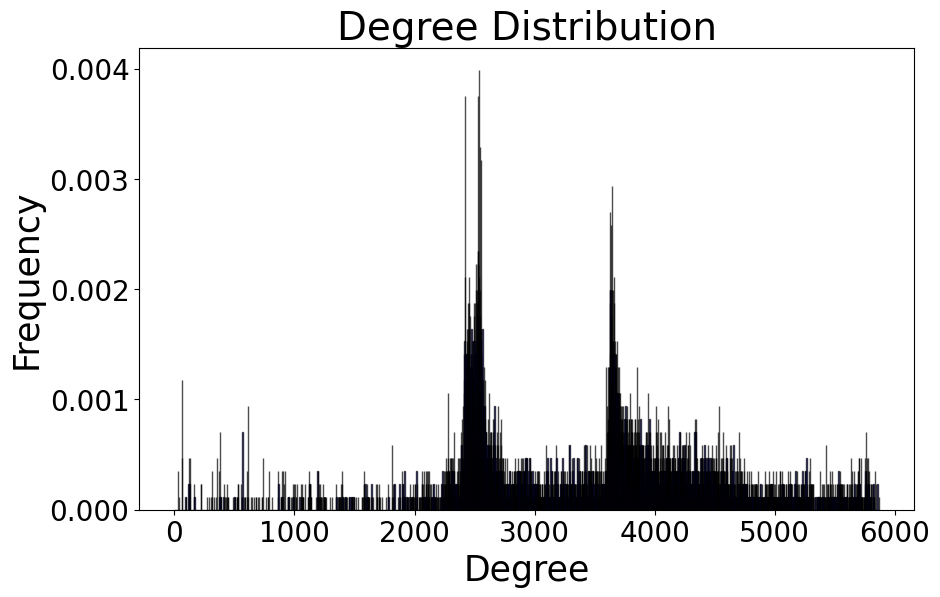

In [ ]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/knd_reciprocal/Cell/
%pwd

for resolution_parameter in resolution_values:
    module_severe = distance_to_module_reciprocal(distance_coordinate=distance_severe, fig_path1=f"./figures/degree_distribution_severe_{resolution_parameter}.png", fig_path2=f"./figures/weight_distribution_severe_{resolution_parameter}.png", threshold_percentile=40, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_severe, file_path=f"module_severe_{resolution_parameter}.json")

In [ ]:
del distance_severe
del module_severe